In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget

import matplotlib.pyplot as plt


import moabb
import numpy as np
import seaborn as sns
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014008, BNCI2014009, EPFLP300,bi2014b
plt.style.use('default')

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)


Not setting metadata
576 matching events found
No baseline correction applied
Not setting metadata
576 matching events found
No baseline correction applied
Not setting metadata
576 matching events found
No baseline correction applied
Not setting metadata
1728 matching events found
No baseline correction applied


In [3]:
epochs


Number of events,1728
Events,NonTarget: 1440Target: 288
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,session_0,run_0
1,1,session_0,run_0
2,1,session_0,run_0
3,1,session_0,run_0
4,1,session_0,run_0
...,...,...,...
1723,1,session_2,run_0
1724,1,session_2,run_0
1725,1,session_2,run_0
1726,1,session_2,run_0


In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler


X = epochs.get_data()
y = labels

X.shape

(1728, 16, 26)

In [6]:
tl.set_backend('cupy')
X = tl.tensor(X)

In [7]:
from hoda.hoda import HODA
from hoda.tenalg import trunc_eigh, lanczos
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

hoda = HODA(
            rank=None,
            max_iter=128,
            tol=1e-16,
            init ='svd',
            shrinkage=('lw','lw'),
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
            lasso=False,
            prune=False,
            combine_pvalue='fisher',
            prune_pvalue=0.05
        )

%lprun -f center hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [16, 16] ...


Timer unit: 1e-09 s

Total time: 0.00844943 s
File: /home/arne/Workspace/PhD/hoda-bci/hoda/gpu_opt.py
Function: center at line 16

Line #      Hits         Time  Per Hit   % Time  Line Contents
    16                                           def center(X, y, classes=None):
    17         3       3938.0   1312.7      0.0      _, *shape = X.shape
    18         3       1687.0    562.3      0.0      order = len(shape)
    19         3        817.0    272.3      0.0      if classes is None:
    20                                                   classes = np.unique(y)
    21         3       1516.0    505.3      0.0      n_classes = len(classes)
    22                                           
    23         3      66761.0  22253.7      0.8      means = tl.zeros((n_classes, *shape), dtype=X.dtype)
    24         3       6285.0   2095.0      0.1      if tl.get_backend() == "cupy":
    25         3     114578.0  38192.7      1.4          X_centered = tl.zeros((n_classes, *X.shape))
    26 

In [8]:
import seaborn as sns

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='f_stat', ax=axs[0])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[1])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.train_info_, x='iteration', y='lambd', ax=axs[3])
    axs[3].set_ylim([0,None])

    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])


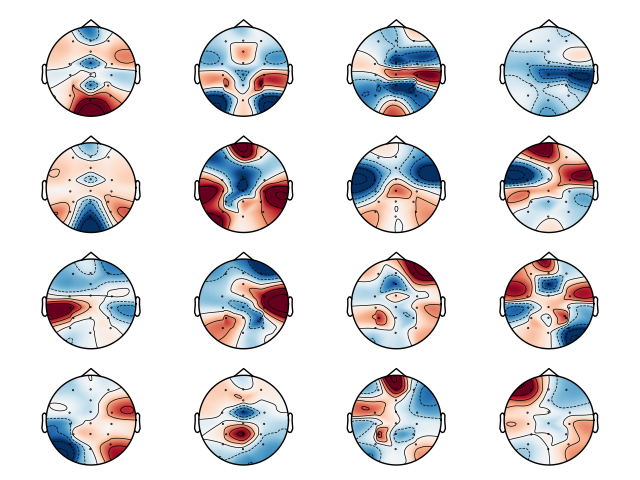

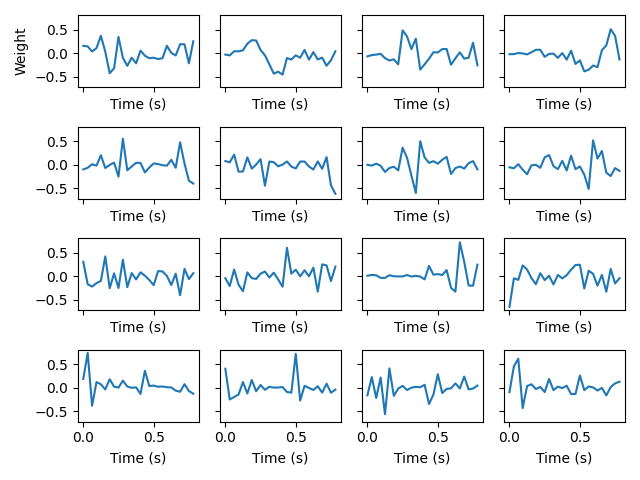

In [9]:
col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


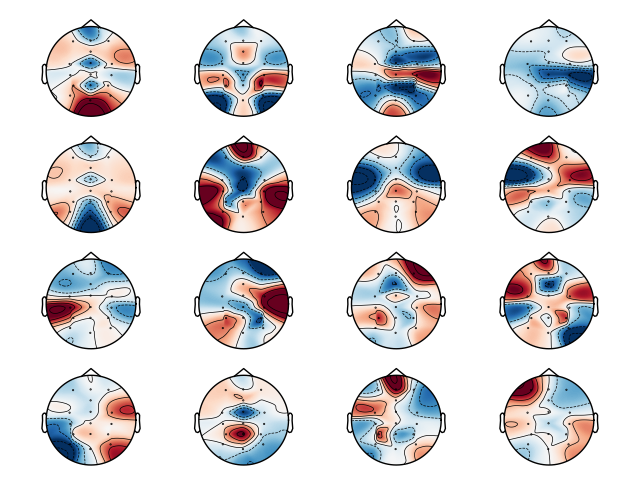

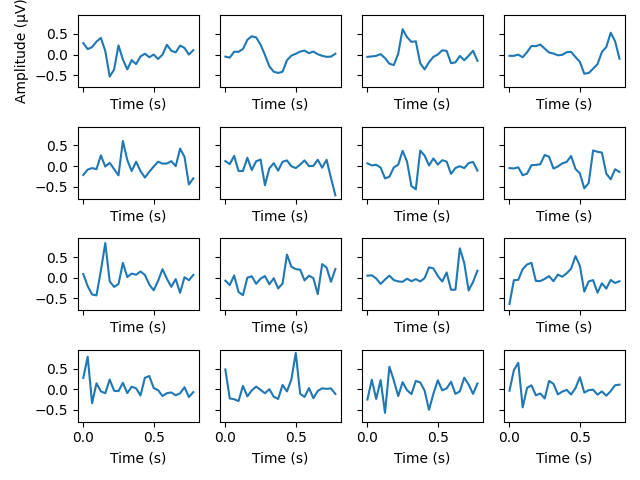

In [10]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

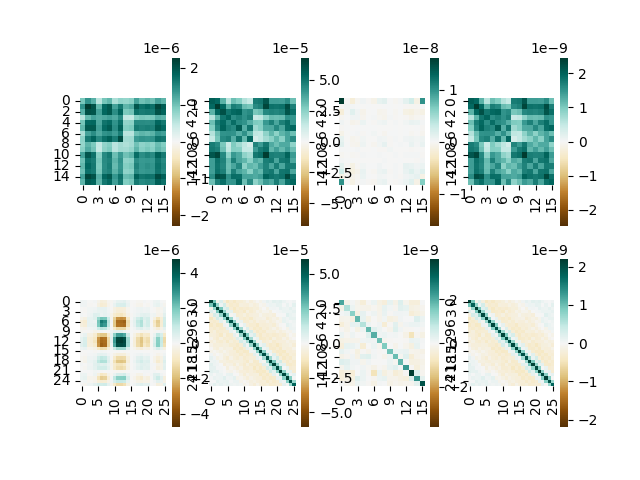

In [11]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  tl.to_numpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [12]:
Xt = hoda.transform(X)

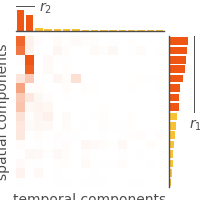

In [35]:
from hoda.hoda import f_oneway
from hoda.gpu_opt import combine_pvalues
import ipdb
import matplotlib
matplotlib.rcParams['axes.linewidth'] = 1
F, p = f_oneway(Xt,y)

import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
color = (239, 85, 19)

cmap_res=256
vals = np.ones((cmap_res, 4))
for i in range(len(color)):
    vals[:,i] = np.linspace(1,color[i]/256,cmap_res)
cmap = ListedColormap(vals)

g = sns.JointGrid()
sns.heatmap(tl.to_numpy(F), vmin=0, ax=g.ax_joint, 
            cmap=cmap,
            cbar=False)
res_sp = tl.to_numpy(tl.tensor([combine_pvalues(p[i,:], method='fisher') for i in range(p.shape[0])]))
res_tmp = tl.to_numpy(tl.tensor([combine_pvalues(p[:,i], method='fisher') for i in range(p.shape[1])]))
#sp_sel = res_sp[:,1]<0.05/p.shape[0]
#tmp_sel = res_tmp[:,1]<0.05/p.shape[1]
sp_sel = res_sp[:,1]<0.05/1e20
tmp_sel = res_tmp[:,1]<0.05/1e20

g.ax_marg_x.bar(np.arange(p.shape[1])[tmp_sel]+0.5, res_tmp[:,0][tmp_sel], color='#ef5513')
g.ax_marg_x.bar(np.arange(p.shape[1])[~tmp_sel]+0.5, res_tmp[:,0][~tmp_sel], color='#f9c134')

g.ax_marg_y.barh(np.arange(p.shape[0])[sp_sel]+0.5, res_sp[:,0][sp_sel], color='#ef5513')
g.ax_marg_y.barh(np.arange(p.shape[0])[~sp_sel]+0.5, res_sp[:,0][~sp_sel], color='#f9c134')

g.ax_joint.set_xticks([])
g.ax_joint.set_yticks([])
g.ax_joint.set_xlabel('temporal components')
g.ax_joint.set_ylabel('spatial components')

darkgray=(.3,.3,.3)
g.ax_marg_y.spines['left'].set_color(darkgray)        # setting up Y-axis tick color to red
g.ax_marg_x.spines['bottom'].set_color(darkgray) 
g.ax_joint.xaxis.label.set_color(darkgray)        #setting up X-axis label color to yellow
g.ax_joint.yaxis.label.set_color(darkgray) 

line_r1, = g.ax_marg_x.plot((0,2), (1400,1400), color=darkgray, linewidth=0.7)
line_r2, = g.ax_marg_y.plot( (500,500), (0,8),color=darkgray, linewidth=0.7)
g.ax_marg_x.annotate('$r_2$',  xy=(2.5, 1100), color=darkgray)
g.ax_marg_y.annotate('$r_1$',  xy=(400,9.8), color=darkgray)

g.figure.set_size_inches(4/2,4/2)
g.figure.savefig('component_selection.pgf', bbox_inches='tight', pad_inches=0)

In [14]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA


order = np.argsort(-F.flatten())
Xt_viz = Xt.reshape((Xt.shape[0],-1))
n_components = min(3, math.prod(Xt.shape[1:]))
#decomp  = PCA(n_components=n_components, whiten=True)
#Xt_viz = decomp.fit_transform(Xt_viz)
Xt_viz = tl.to_numpy((Xt_viz[:,order[:n_components]]))

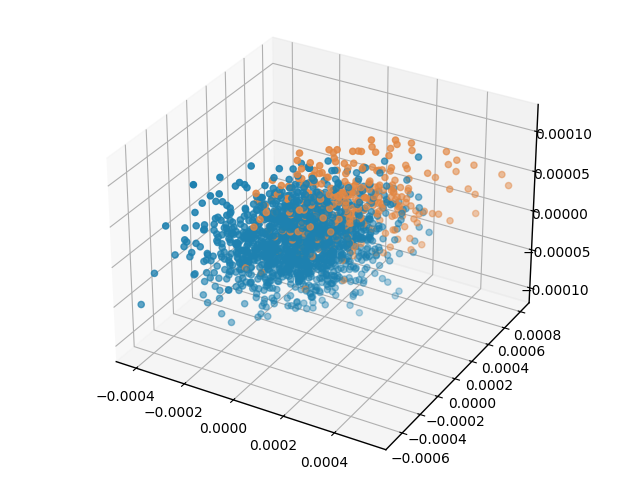

In [15]:
import re, seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
c = np.vectorize(cmap.get)(y)

if Xt_viz.shape[-1] < 2:
    pass
elif Xt_viz.shape[-1] <3:
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0],Xt_viz[:,1], c=c)   
else:
    # axes instance
    fig = plt.figure()
    ax = Axes3D(fig)
    fig.add_axes(ax)
    
    sc = ax.scatter(Xt_viz[:,0],Xt_viz[:,1],Xt_viz[:,2], c=c)
#ax.set_aspect('equal')


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


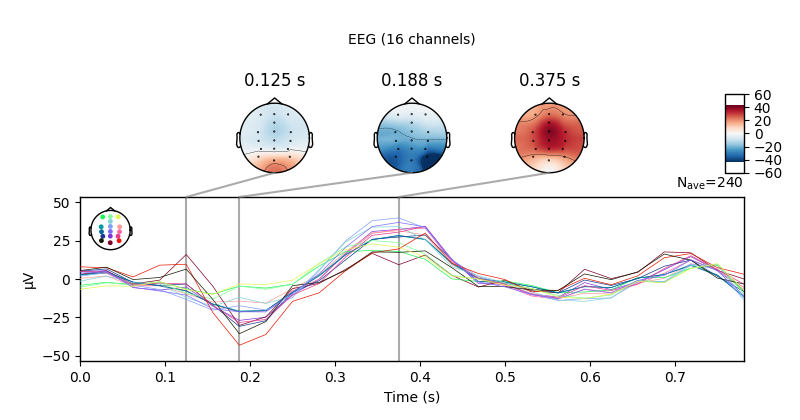

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


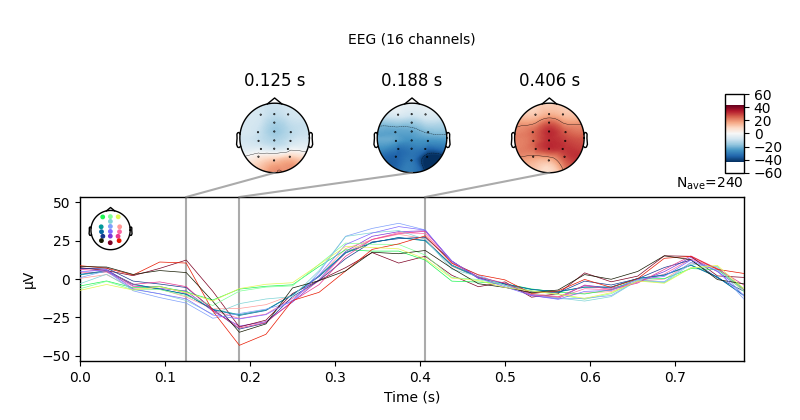

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


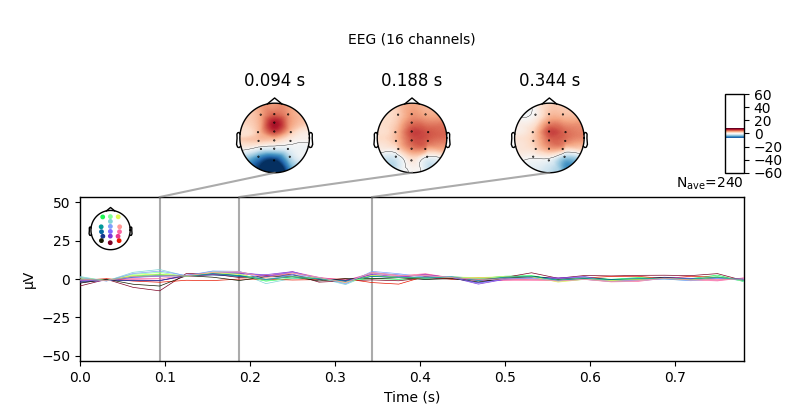

In [16]:
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
vmax = np.max(np.abs(target.data))
vmax = max(vmax, np.max(np.abs(non_target.data)))
vmax *=1.1e6

joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-vmax,vmax]),
        unit=True,
    )
)


contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_rec.plot_joint(**joint_args)

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast_defl = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_defl.plot_joint(**joint_args)

In [17]:
#contrast_rec.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

In [18]:
#contrast_defl.animate_topomap(times = contrast_defl.times, frame_rate=contrast.info['sfreq'], blit=False, butterfly=True)

## Classification

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
Xt_flat = StandardScaler().fit_transform(Xt_flat)
logreg = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', class_weight='balanced', scoring='roc_auc')
logreg.fit(Xt_flat, y)
score_pred = logreg.decision_function(Xt_flat)


df = pd.DataFrame(dict(score=score_pred,y=y))
g = sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))

fig, ax = plt.subplots(1,1)
_ = ax.bar(np.arange(Xt_flat.shape[1]), np.abs(logreg.coef_.squeeze()))


KeyboardInterrupt

